In [1]:
!pip install scikit-learn


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Social_Network_Ads.csv')

In [4]:
df.head()


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df = pd.read_csv('Social_Network_Ads.csv',index_col='User ID')

In [6]:
df = df.iloc[:,1:]

In [7]:
df.sample(5)

,Age,EstimatedSalary,Purchased
User ID,,,
15660200,37,71000,0
15601550,36,54000,0
15757632,39,59000,0
15662067,19,26000,0
15666141,18,68000,0


In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)

In [9]:
from sklearn.preprocessing import StandardScaler

# takes df but returns numpy arr

scaler = StandardScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
scaler.mean_


array([3.78642857e+01, 6.98071429e+04])

In [11]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns = X_test.columns)

In [12]:
X_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.864286,69807.142857
std,10.218201,34641.201654
min,18.000000,15000.000000
25%,30.000000,43000.000000
50%,37.000000,70500.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


In [13]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


Text(0.5, 1.0, 'After Scaling')

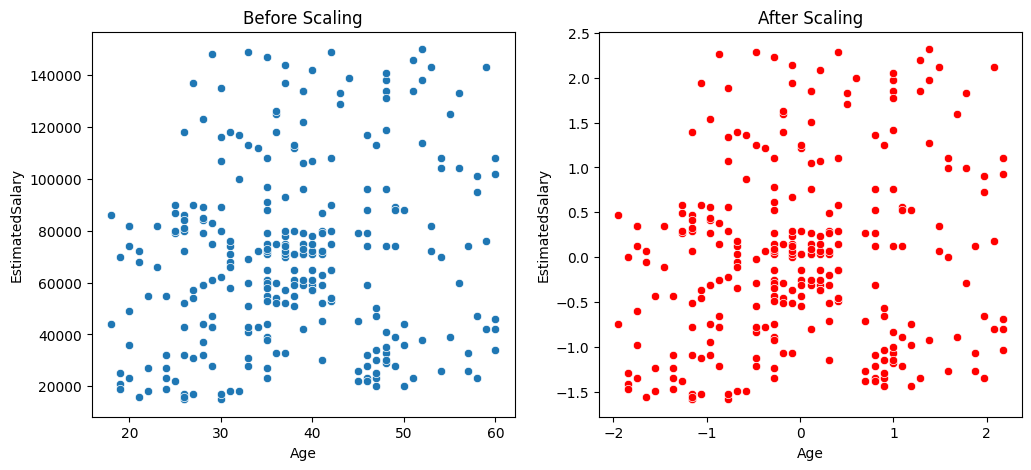

In [14]:
fig,(ax1,ax2) =  plt.subplots(ncols=2,figsize=(12,5))
sns.scatterplot(x=X_train['Age'], y=X_train['EstimatedSalary'],ax=ax1)
ax1.set_title("Before Scaling")
sns.scatterplot(x=X_train_scaled['Age'],y=X_train_scaled['EstimatedSalary'],ax=ax2,color='red')
ax2.set_title("After Scaling")

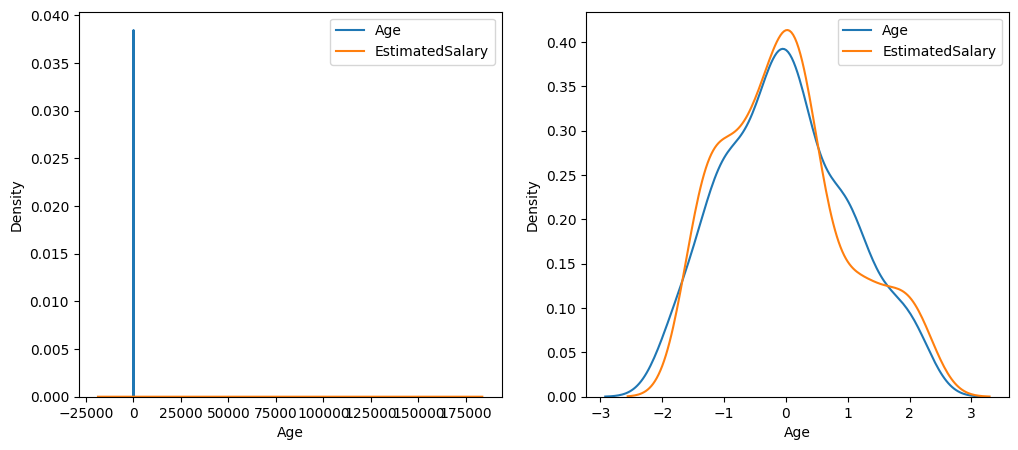

In [15]:

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

sns.kdeplot(X_train['Age'], ax=ax1, label='Age')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1, label='EstimatedSalary')
ax1.legend()

sns.kdeplot(X_train_scaled['Age'], ax=ax2, label='Age')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2, label='EstimatedSalary')
ax2.legend()

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
lr = LogisticRegression()
lr_Scaled = LogisticRegression()

lr.fit(X_train,Y_train)
lr_Scaled.fit(X_train_scaled,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [18]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_Scaled.predict(X_test_scaled)

In [19]:
from sklearn.metrics import accuracy_score

Actual 0.875
Scaled 0.8666666666666667


## What if we have Outliers

In [21]:
df = pd.concat([df, pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]})], ignore_index=True)

In [22]:
df.sample(5)


,Age,EstimatedSalary,Purchased
125,39,61000,0
254,50,44000,0
401,90,250000,1
378,41,87000,1
292,55,39000,1


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

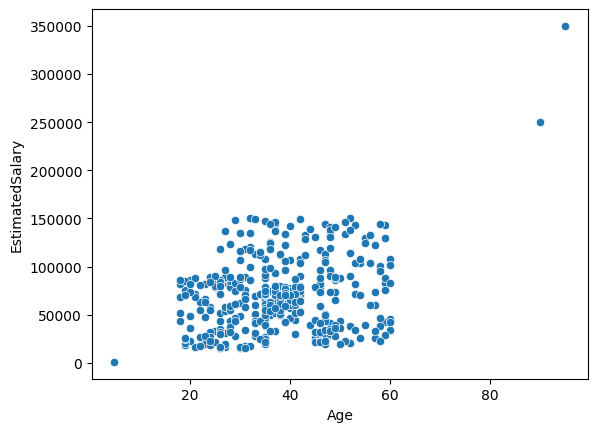

In [23]:
sns.scatterplot(x=df['Age'],y=df['EstimatedSalary'])

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)
X_train.shape,X_test.shape

((282, 2), (121, 2))

In [25]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

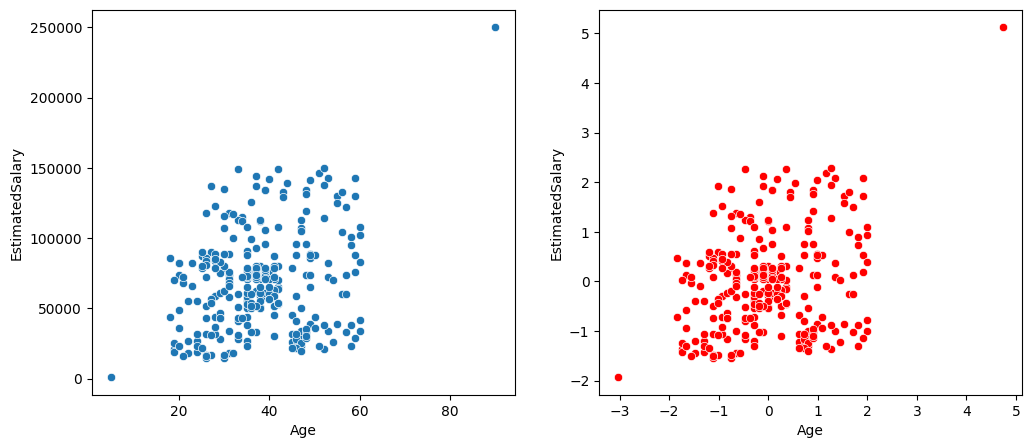

In [27]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

sns.scatterplot(x=X_train['Age'],y=X_train['EstimatedSalary'],ax=ax1)
sns.scatterplot(x=X_train_scaled['Age'],y=X_train_scaled['EstimatedSalary'],ax=ax2,color='red')

## Standardisation kyay b use karo loss to nathi j but... ankh bandh kari ne following algos ma we can use standardisation


1. K-Means
2. K-Nearest-Neighbour
3. Principal Component Analysis(PCA)
4. Artificial Neural Network
5. Gradient Descent